In [45]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
# Carregando a base de dados Varejo
df = pd.read_csv(r"C:\Users\Usuário\Documents\Miniprojeto_JessicaFinardi_DadosV2\Dados\Base_Varejo.csv", sep=";")

# Exibindo as 5 primeiras linhas.
df.head(5)

In [ ]:
# Exibindo informações
def relatorio(df):
    print(f"\nTotal de linhas:   {df.shape[0]:,}")
    print(f"Total de colunas: {df.shape[1]:,}")
    print("\n📌 Valores ausentes por coluna:")
    nulos = df.isnull().sum()
    pct_nulos = (df.isnull().sum() / len(df) * 100).round(2)
    
    relatorio = pd.DataFrame({
        'Tipo': df.dtypes,
        'Nulos': nulos,
        '% Nulos': pct_nulos,
        'Únicos': df.nunique()
    })
    print(relatorio)

relatorio(df)

In [ ]:
# Contagem de nulos por coluna
nulos = df.isnull().sum()
print("\nQuantidade de valores nulos por coluna:\n")
print(nulos)


In [ ]:
# Quantidade de linhas duplicadas onde todos os campos são iguais.
duplicadas = df.duplicated().sum()
print(f"\nQuantidade de linhas duplicadas: {duplicadas}\n")


In [ ]:
# Verificando datas inválidas
df["DATA"] = pd.to_datetime(df["DATA"], errors="coerce")
datas_invalidas = df[df["DATA"].isnull()]
print("\nDatas inválidas:\n")
print(datas_invalidas)

In [51]:
# Criando uma cópia do database
df_limpo = df.copy()

In [ ]:
# Removendo colunas Unnamed: 10, Unnamed: 11, Unnamed: 12 e Unnamed: 13. 
df_remove_coluna = df.dropna(axis=1, how='all')
print(df_remove_coluna)


In [ ]:
print(f"Quantidade de linhas duplicadas: {df.duplicated().sum()}")
print()

# Removendo duplicatas, e mantendo a primeira.
df_limpo = df.drop_duplicates(keep='first')

# Reindexação
df_limpo = df_limpo.reset_index(drop=True)

# Após remoção das duplicatas
print(f"Total de linhas após a remoção das duplicatas: {len(df_limpo)} linhas")


In [ ]:
# Covertendo a coluna data para datatime.
df_limpo['DATA'] = pd.to_datetime(df_limpo['DATA'], format='%d/%m/%Y')
print(df_limpo)

In [ ]:
# Verificação de estatísticas
print(f'''
Contagem: {df_limpo['CL_FHL'].count()}
Média: {df_limpo['CL_FHL'].mean()}
Mediana: {df_limpo['CL_FHL'].median()}
Moda: {df_limpo['CL_FHL'].mode()[0]}
Desvio padrão: {df_limpo['CL_FHL'].std()}
Mínimo: {df_limpo['CL_FHL'].min()}
Máximo: {df_limpo['CL_FHL'].max()}
q1: {df_limpo['CL_FHL'].quantile(0.25)}
q2: {df_limpo['CL_FHL'].quantile(0.50)}
q3: {df_limpo['CL_FHL'].quantile(0.75)}
''')


Quais são os produtos mais consumidos por cada gênero?
Alguma das categorias é mais vendida em um gênero específico?

In [ ]:
# Agrupando por genero e quantidade de compras em cada segmento.
genero_categoria = df_limpo.groupby(['CL_GENERO', 'PR_CAT'])['CO_ID'].count()
print(genero_categoria)

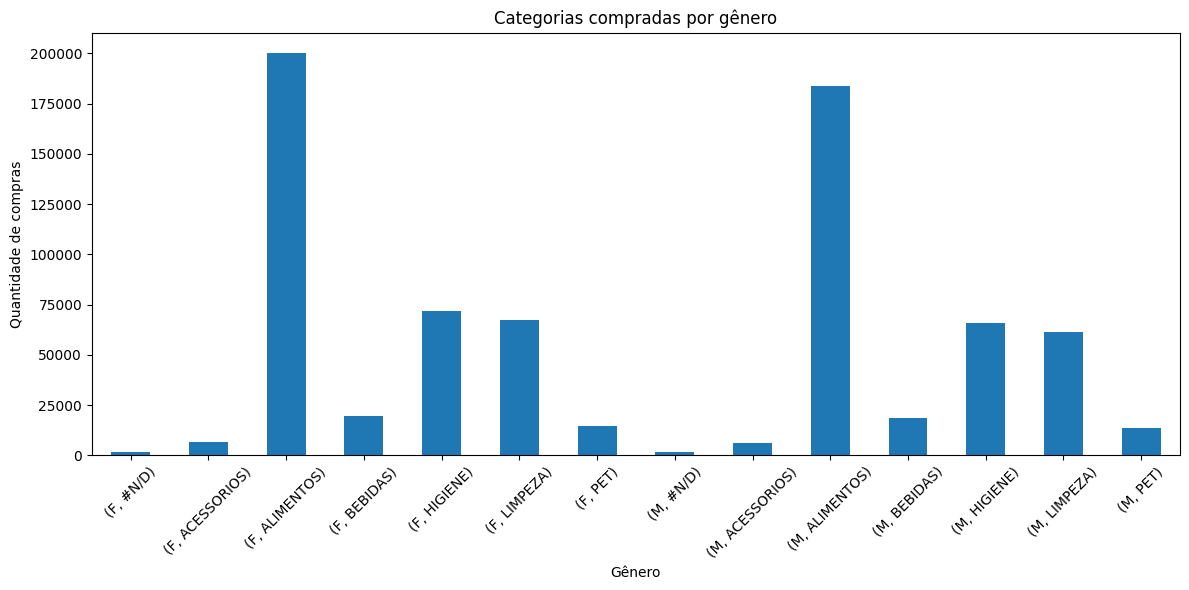

In [57]:
import matplotlib.pyplot as plt

genero_categoria = df_limpo.groupby(['CL_GENERO', 'PR_CAT'])['CO_ID'].count()

genero_categoria.plot(kind='bar', figsize=(12,6))

plt.title('Categorias compradas por gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de compras')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Quais são os produtos mais consumidos por cada gênero?
Alguma das categorias é mais vendida em um gênero. Verifica-se que em ambos os gêneros, a categoria mais vendida é a de alimentos, seguida dos produtos de higiene e limpeza que seguem parâmetros parecidos em ambos os gêneros. Para todas as categorias não temos valores discrepantes, mas observa-se que o gênero feminino realiza mais compras em todos os segmentos.


A quantidade de filhos pode estar influenciando no comportamento de compras dos clientes em algum segmento? 
Clientes com mais filhos consomem mais alguma categoria em específico?

In [58]:
# Agrupando por quantidade de filhos versus quantidade comprada em cada segmento.
filhos_categoria = df_limpo.groupby(['CL_FHL', 'PR_CAT'])['CO_ID'].count()
print(filhos_categoria)

CL_FHL  PR_CAT    
0       #N/D            1683
        ACESSORIOS      6755
        ALIMENTOS     201670
        BEBIDAS        19991
        HIGIENE        72302
        LIMPEZA        67625
        PET            14960
1       #N/D             406
        ACESSORIOS      1564
        ALIMENTOS      47613
        BEBIDAS         4901
        HIGIENE        17018
        LIMPEZA        15782
        PET             3561
2       #N/D             406
        ACESSORIOS      1647
        ALIMENTOS      49269
        BEBIDAS         4895
        HIGIENE        17647
        LIMPEZA        16583
        PET             3721
3       #N/D             400
        ACESSORIOS      1689
        ALIMENTOS      48284
        BEBIDAS         4812
        HIGIENE        17487
        LIMPEZA        16148
        PET             3587
4       #N/D             333
        ACESSORIOS      1216
        ALIMENTOS      37361
        BEBIDAS         3665
        HIGIENE        13248
        LIMPEZA        1

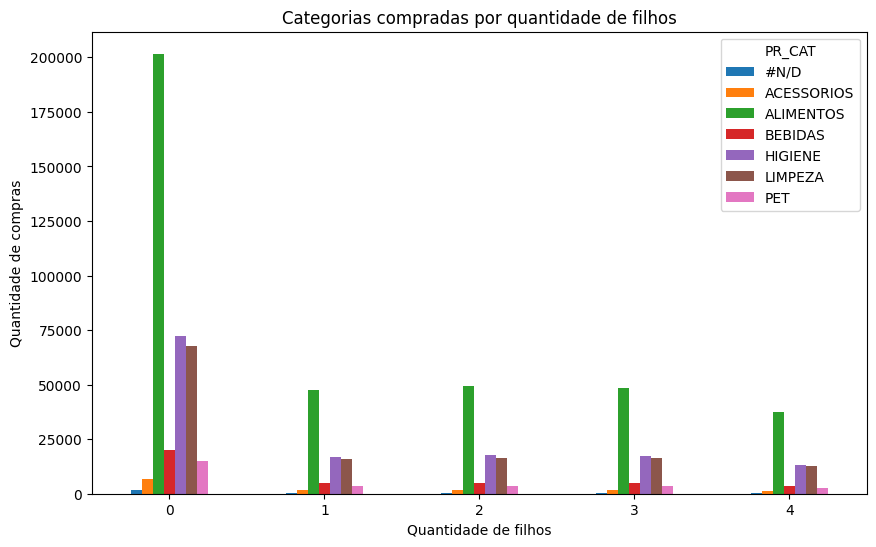

In [59]:
import matplotlib.pyplot as plt

filhos_categoria = df_limpo.groupby(['CL_FHL', 'PR_CAT'])['CO_ID'].count().unstack()

filhos_categoria.plot(kind='bar', figsize=(10,6))

plt.title('Categorias compradas por quantidade de filhos')
plt.xlabel('Quantidade de filhos')
plt.ylabel('Quantidade de compras')

plt.xticks(rotation=0)

plt.show()

Nessa análise observa-se que independente dos números de filhos, a categoria de alimentação lidera no segmento, representando mais da metade das compras.
É possível verificar que o grupo sem filhos lidera as compras em todos os segmentos, o que poderia significar que temos mais clientes sem filhos na base. Nos grupos com filhos observa-se que as categorias de higiene e limpeza seguem valores parecidos mostrando um comportamento de consumo mais ligado a rotina doméstica. Independentemente  da quantidade de filhos observou-se um padrão parecido de gastos com pets, indicando que possuir filhos não estaria impactando nesse segmento.

Quais são os 10 produtos mais vendidos? 

In [60]:
# Top 10 dos produtos mais vendidos
produtos_vendidos = df_limpo.groupby('PR_NOME')['CO_ID'].count().sort_values(ascending=False)
print(produtos_vendidos.head(10))

PR_NOME
PRESUNTO COZIDO       12719
SARDINHA               6610
BANANA                 6518
ESCOVA DE DENTE        6518
GEL                    6517
PAPINHA INFANTIL       6515
MODELADOR              6505
CERA                   6502
CEBOLA                 6501
LIMPADOR PERFUMADO     6501
Name: CO_ID, dtype: int64


Observa-se através do top 10 em vendas, que os produtos são bastante diversificados, sendo desde alimentos à produtos de limpeza. O que demonstra que a empresa tem uma boa saída de produtos em todas as categorias. Significando que são produtos que fazem parte da rotina diária dos consumidores. O produto que mais se destaca sendo praticamente o dobro do segundo colocado, é o presunto cozido. Isso demonstra que é um item de compra recorrente dos consumidores, que provavelmente gostam bastante do produto. A partir do segundo colocado temos valores de vendas bem próximos nas demais categorias, mostrando vendas equilibradas nesses segmentos.

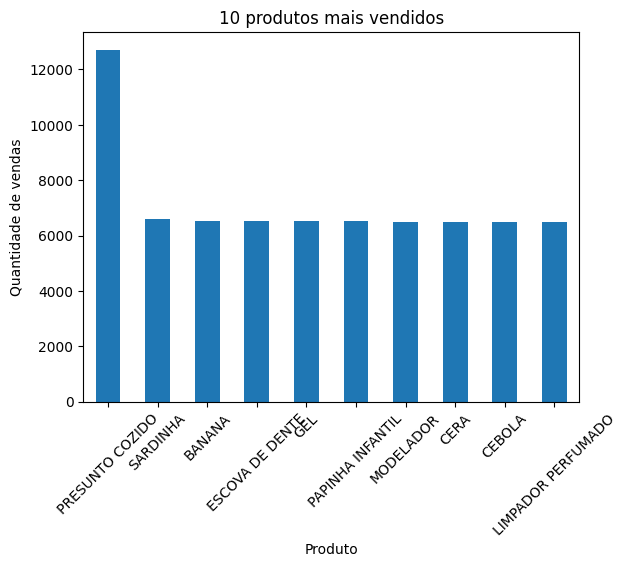

In [61]:
import matplotlib.pyplot as plt

produtos_vendidos = df_limpo.groupby('PR_NOME')['CO_ID'].count().sort_values(ascending=False)

top10 = produtos_vendidos.head(10)

top10.plot(kind='bar')

plt.title('10 produtos mais vendidos')
plt.xlabel('Produto')
plt.ylabel('Quantidade de vendas')

plt.xticks(rotation=45)

plt.show()

In [62]:
df_limpo.to_csv('df_limpo.csv', index=False)

In [63]:
# Exibindo informações
def relatorio(df):
    print(f"\nTotal de linhas:   {df_limpo.shape[0]:,}")
    print(f"Total de colunas: {df_limpo.shape[1]:,}")
    print("\n📌 Valores ausentes por coluna:")
    nulos = df_limpo.isnull().sum()
    pct_nulos = (df_limpo.isnull().sum() / len(df_limpo) * 100).round(2)
    
    relatorio = pd.DataFrame({
        'Tipo': df_limpo.dtypes,
        'Nulos': nulos,
        '% Nulos': pct_nulos,
        'Únicos': df_limpo.nunique()
    })
    print(relatorio)

relatorio(df)


Total de linhas:   733,447
Total de colunas: 14

📌 Valores ausentes por coluna:
                       Tipo   Nulos  % Nulos  Únicos
DATA         datetime64[us]  428636    58.44     141
CO_ID                 int64       0     0.00   18471
CL_ID                 int64       0     0.00    1000
CL_GENERO               str       0     0.00       2
CL_EC                 int64       0     0.00       5
CL_FHL                int64       0     0.00       5
CL_SEG                  str       0     0.00       3
PR_ID                 int64       0     0.00     229
PR_CAT                  str       0     0.00       7
PR_NOME                 str       0     0.00     118
Unnamed: 10         float64  733447   100.00       0
Unnamed: 11         float64  733447   100.00       0
Unnamed: 12         float64  733447   100.00       0
Unnamed: 13         float64  733447   100.00       0
